## Setup and Memory Monitoring

In [1]:
import gc
import os
import numpy as np
import pandas as pd
import psutil
from sklearn.model_selection import TimeSeriesSplit

pd.set_option('display.max_columns', None)

def show_memory(label=""):
    """Print current process RSS memory -- verifies each optimization actually helps."""
    mem_gb = psutil.Process(os.getpid()).memory_info().rss / 1e9
    print(f"[{label}] Process memory: {mem_gb:.2f} GB")

show_memory("notebook start")

[notebook start] Process memory: 0.24 GB


## Memory-Efficient Data Load

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/Supply_Chain_Demand_Forecasting/data/processed/feature_engineered_data.csv'

NEEDED_COLS = ['store_id', 'item_id', 'date', 'units_sold', 'lag_1', 'lag_7']

dtype_map = {
    'store_id': 'category',
    'item_id': 'category',
    'units_sold': 'float32',   # kept float32, not int, since source column may carry NaN-safe float type
    'lag_1': 'float32',
    'lag_7': 'float32',
}

CHUNK_SIZE = 2_000_000  # rows per chunk -- tune down further if RAM is still tight

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
chunks = []
for i, chunk in enumerate(pd.read_csv(
    DATA_PATH,
    usecols=NEEDED_COLS,
    dtype=dtype_map,
    parse_dates=['date'],
    chunksize=CHUNK_SIZE
)):
    chunks.append(chunk)
    print(f"Chunk {i}: {chunk.shape[0]:,} rows read")

show_memory("after chunked read (chunks list held)")

Chunk 0: 2,000,000 rows read
Chunk 1: 2,000,000 rows read
Chunk 2: 2,000,000 rows read
Chunk 3: 2,000,000 rows read
Chunk 4: 1,415,478 rows read
[after chunked read (chunks list held)] Process memory: 0.58 GB


In [4]:
df = pd.concat(chunks, ignore_index=True)

del chunks
gc.collect()

show_memory("after concat + chunk cleanup")
print("Final loaded shape:", df.shape)
df.dtypes

[after concat + chunk cleanup] Process memory: 0.86 GB
Final loaded shape: (9415478, 6)


,0
item_id,object
store_id,object
units_sold,float32
date,datetime64[ns]
lag_1,float32
lag_7,float32


In [5]:
df.sort_values(['store_id', 'item_id', 'date'], inplace=True)
df.reset_index(drop=True, inplace=True)

show_memory("after sort")
df.head(10)

[after sort] Process memory: 0.86 GB


,item_id,store_id,units_sold,date,lag_1,lag_7
0,FOODS_1_001,CA_1,2.0,2011-02-26,4.0,1.0
1,FOODS_1_001,CA_1,2.0,2011-02-27,2.0,2.0
2,FOODS_1_001,CA_1,0.0,2011-02-28,2.0,0.0
3,FOODS_1_001,CA_1,2.0,2011-03-01,0.0,2.0
4,FOODS_1_001,CA_1,1.0,2011-03-02,2.0,2.0
5,FOODS_1_001,CA_1,7.0,2011-03-03,1.0,2.0
6,FOODS_1_001,CA_1,1.0,2011-03-04,7.0,4.0
7,FOODS_1_001,CA_1,2.0,2011-03-05,1.0,2.0
8,FOODS_1_001,CA_1,3.0,2011-03-06,2.0,2.0
9,FOODS_1_001,CA_1,0.0,2011-03-07,3.0,0.0


## Naive and Seasonal Naive: Intuition

In [6]:
df['naive_pred'] = df['lag_1']
df['seasonal_naive_pred'] = df['lag_7']

show_memory("after adding baseline prediction columns")

[after adding baseline prediction columns] Process memory: 0.86 GB


In [7]:
valid_mask = df['naive_pred'].notna() & df['seasonal_naive_pred'].notna()
print("Rows with valid baseline predictions:", valid_mask.sum(), "/", len(df))

df.loc[valid_mask, ['store_id', 'item_id', 'date', 'units_sold', 'naive_pred', 'seasonal_naive_pred']].head(10)

Rows with valid baseline predictions: 9415478 / 9415478


,store_id,item_id,date,units_sold,naive_pred,seasonal_naive_pred
0,CA_1,FOODS_1_001,2011-02-26,2.0,4.0,1.0
1,CA_1,FOODS_1_001,2011-02-27,2.0,2.0,2.0
2,CA_1,FOODS_1_001,2011-02-28,0.0,2.0,0.0
3,CA_1,FOODS_1_001,2011-03-01,2.0,0.0,2.0
4,CA_1,FOODS_1_001,2011-03-02,1.0,2.0,2.0
5,CA_1,FOODS_1_001,2011-03-03,7.0,1.0,2.0
6,CA_1,FOODS_1_001,2011-03-04,1.0,7.0,4.0
7,CA_1,FOODS_1_001,2011-03-05,2.0,1.0,2.0
8,CA_1,FOODS_1_001,2011-03-06,3.0,2.0,2.0
9,CA_1,FOODS_1_001,2011-03-07,0.0,3.0,0.0


### why WMAPE was chosen ?
### Retail demand often contains many zero-sales days. WMAPE is more robust than traditional MAPE because it avoids instability caused by dividing by very small actual values.

## Evaluation Metrics (WMAPE, Not Plain MAPE)

In [8]:
def evaluate_forecast(actual, predicted, label=""):
    """Compute MAE, RMSE, and zero-safe WMAPE on a Series pair. No copies of the parent df are made."""
    mask = predicted.notna()
    actual_m = actual[mask]
    predicted_m = predicted[mask]

    mae = np.mean(np.abs(actual_m - predicted_m))
    rmse = np.sqrt(np.mean((actual_m - predicted_m) ** 2))
    wmape = np.sum(np.abs(actual_m - predicted_m)) / np.sum(actual_m)

    print(f"--- {label} ---")
    print(f"MAE:   {mae:.3f}")
    print(f"RMSE:  {rmse:.3f}")
    print(f"WMAPE: {wmape*100:.2f}%")
    print(f"(evaluated on {mask.sum():,} rows)\n")

    return {'label': label, 'mae': mae, 'rmse': rmse, 'wmape': wmape, 'n_rows': int(mask.sum())}

## Walk-Forward Evaluation

In [9]:
FORECAST_HORIZON = 28  # matches M5's official evaluation horizon and Item #8's setup

unique_dates = np.sort(df['date'].unique())
tscv = TimeSeriesSplit(n_splits=5, test_size=FORECAST_HORIZON)

fold_boundaries = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_dates)):
    test_start = unique_dates[test_idx[0]]
    test_end = unique_dates[test_idx[-1]]
    fold_boundaries.append((fold, test_start, test_end))
    print(f"Fold {fold}: test {pd.Timestamp(test_start).date()} -> {pd.Timestamp(test_end).date()}")

del unique_dates
gc.collect()
show_memory("after fold boundary calculation")

Fold 0: test 2016-01-04 -> 2016-01-31
Fold 1: test 2016-02-01 -> 2016-02-28
Fold 2: test 2016-02-29 -> 2016-03-27
Fold 3: test 2016-03-28 -> 2016-04-24
Fold 4: test 2016-04-25 -> 2016-05-22
[after fold boundary calculation] Process memory: 1.35 GB


In [10]:
EVAL_COLS = ['date', 'units_sold', 'naive_pred', 'seasonal_naive_pred']
baseline_results = []

for fold, test_start, test_end in fold_boundaries:
    # Boolean mask + column selection creates a lightweight view for evaluation,
    # not a full-width copy of df -- keeps each fold's memory cost proportional to
    # 28 days of data (~168K rows here), not the full 11M-row frame.
    fold_mask = (df['date'] >= test_start) & (df['date'] <= test_end)
    fold_slice = df.loc[fold_mask, EVAL_COLS]

    naive_metrics = evaluate_forecast(
        fold_slice['units_sold'], fold_slice['naive_pred'], label=f"Fold {fold} — Naive"
    )
    seasonal_metrics = evaluate_forecast(
        fold_slice['units_sold'], fold_slice['seasonal_naive_pred'], label=f"Fold {fold} — Seasonal Naive"
    )

    naive_metrics.update({'fold': fold, 'model': 'naive'})
    seasonal_metrics.update({'fold': fold, 'model': 'seasonal_naive'})
    baseline_results.append(naive_metrics)
    baseline_results.append(seasonal_metrics)

    del fold_slice, fold_mask
    gc.collect()

show_memory("after all folds evaluated")
baseline_df = pd.DataFrame(baseline_results)
baseline_df

--- Fold 0 — Naive ---
MAE:   1.046
RMSE:  2.372
WMAPE: 88.23%
(evaluated on 170,650 rows)

--- Fold 0 — Seasonal Naive ---
MAE:   1.076
RMSE:  2.501
WMAPE: 90.73%
(evaluated on 170,650 rows)

--- Fold 1 — Naive ---
MAE:   1.092
RMSE:  2.500
WMAPE: 87.28%
(evaluated on 170,704 rows)

--- Fold 1 — Seasonal Naive ---
MAE:   1.116
RMSE:  2.538
WMAPE: 89.22%
(evaluated on 170,704 rows)

--- Fold 2 — Naive ---
MAE:   1.111
RMSE:  2.443
WMAPE: 87.07%
(evaluated on 170,732 rows)

--- Fold 2 — Seasonal Naive ---
MAE:   1.116
RMSE:  2.447
WMAPE: 87.47%
(evaluated on 170,732 rows)

--- Fold 3 — Naive ---
MAE:   1.124
RMSE:  2.494
WMAPE: 86.92%
(evaluated on 170,744 rows)

--- Fold 3 — Seasonal Naive ---
MAE:   1.145
RMSE:  2.518
WMAPE: 88.58%
(evaluated on 170,744 rows)

--- Fold 4 — Naive ---
MAE:   1.168
RMSE:  2.468
WMAPE: 86.11%
(evaluated on 170,744 rows)

--- Fold 4 — Seasonal Naive ---
MAE:   1.190
RMSE:  2.493
WMAPE: 87.74%
(evaluated on 170,744 rows)

[after all folds evaluated] Process

,label,mae,rmse,wmape,n_rows,fold,model
0,Fold 0 — Naive,1.046241,2.372359,0.882316,170650,0,naive
1,Fold 0 — Seasonal Naive,1.075822,2.501285,0.907262,170650,0,seasonal_naive
2,Fold 1 — Naive,1.091720,2.499781,0.872750,170704,1,naive
3,Fold 1 — Seasonal Naive,1.116037,2.537790,0.892190,170704,1,seasonal_naive
4,Fold 2 — Naive,1.111198,2.443391,0.870689,170732,2,naive
5,Fold 2 — Seasonal Naive,1.116264,2.446978,0.874659,170732,2,seasonal_naive
6,Fold 3 — Naive,1.123717,2.493824,0.869239,170744,3,naive
7,Fold 3 — Seasonal Naive,1.145083,2.518102,0.885766,170744,3,seasonal_naive
8,Fold 4 — Naive,1.167813,2.468412,0.861092,170744,4,naive
9,Fold 4 — Seasonal Naive,1.189951,2.493471,0.877416,170744,4,seasonal_naive


## Summary Table Across All Folds

In [11]:
summary = (
    baseline_df.groupby('model')[['mae', 'rmse', 'wmape']]
    .mean()
    .rename(columns={'mae': 'avg_mae', 'rmse': 'avg_rmse', 'wmape': 'avg_wmape'})
    .round(4)
)
summary['avg_wmape_pct'] = (summary['avg_wmape'] * 100).round(2)
summary

,avg_mae,avg_rmse,avg_wmape,avg_wmape_pct
model,,,,
naive,1.1081,2.4556,0.8712,87.120003
seasonal_naive,1.1286,2.4995,0.8875,88.750000


## Visualize Naive vs. Seasonal Naive vs. Actual (Sample Product)

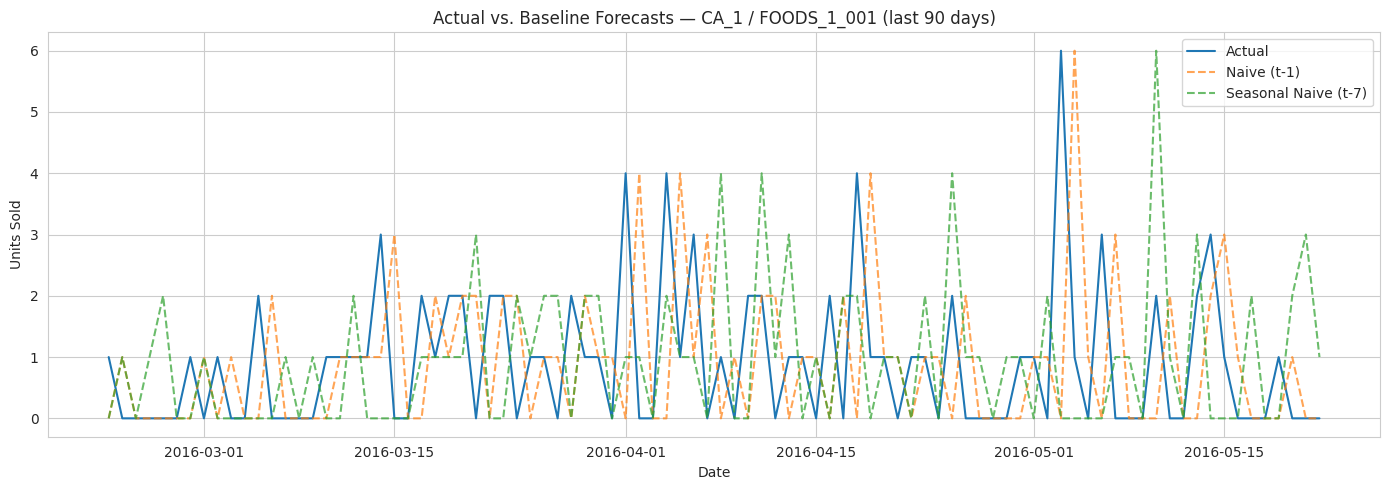

[after visualization] Process memory: 1.36 GB


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

sample_key = df[['store_id', 'item_id']].drop_duplicates().iloc[0]

# Filter + select only plotting columns -- avoids copying the full-width frame for one product's slice
plot_cols = ['date', 'units_sold', 'naive_pred', 'seasonal_naive_pred']
sample_mask = (df['store_id'] == sample_key['store_id']) & (df['item_id'] == sample_key['item_id'])
sample_df = df.loc[sample_mask, plot_cols].sort_values('date').tail(90)

plt.figure(figsize=(14, 5))
plt.plot(sample_df['date'], sample_df['units_sold'], label='Actual', linewidth=1.5)
plt.plot(sample_df['date'], sample_df['naive_pred'], label='Naive (t-1)', linestyle='--', alpha=0.7)
plt.plot(sample_df['date'], sample_df['seasonal_naive_pred'], label='Seasonal Naive (t-7)', linestyle='--', alpha=0.7)
plt.title(f"Actual vs. Baseline Forecasts — {sample_key['store_id']} / {sample_key['item_id']} (last 90 days)")
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

del sample_df, sample_mask
gc.collect()
show_memory("after visualization")

## Save Baseline Results

In [13]:
OUT_PATH = '/content/drive/MyDrive/Supply_Chain_Demand_Forecasting/data/processed/baseline_metrics.csv'

baseline_df.to_csv(OUT_PATH, index=False)
show_memory("after save")
print("Saved baseline_metrics.csv —", baseline_df.shape)
baseline_df

[after save] Process memory: 1.36 GB
Saved baseline_metrics.csv — (10, 7)


,label,mae,rmse,wmape,n_rows,fold,model
0,Fold 0 — Naive,1.046241,2.372359,0.882316,170650,0,naive
1,Fold 0 — Seasonal Naive,1.075822,2.501285,0.907262,170650,0,seasonal_naive
2,Fold 1 — Naive,1.091720,2.499781,0.872750,170704,1,naive
3,Fold 1 — Seasonal Naive,1.116037,2.537790,0.892190,170704,1,seasonal_naive
4,Fold 2 — Naive,1.111198,2.443391,0.870689,170732,2,naive
5,Fold 2 — Seasonal Naive,1.116264,2.446978,0.874659,170732,2,seasonal_naive
6,Fold 3 — Naive,1.123717,2.493824,0.869239,170744,3,naive
7,Fold 3 — Seasonal Naive,1.145083,2.518102,0.885766,170744,3,seasonal_naive
8,Fold 4 — Naive,1.167813,2.468412,0.861092,170744,4,naive
9,Fold 4 — Seasonal Naive,1.189951,2.493471,0.877416,170744,4,seasonal_naive


In [14]:
# Final cleanup -- release the full dataframe now that everything needed has been saved
del df
gc.collect()
show_memory("notebook end (df released)")

[notebook end (df released)] Process memory: 1.36 GB


## Key Takeaways
###Successfully established Naive and Seasonal Naive forecasting models as benchmark baselines for the project.
###Evaluated baseline performance using Walk-Forward Validation (TimeSeriesSplit) to prevent data leakage and simulate real-world forecasting.
###Used WMAPE as the primary evaluation metric because it is more suitable for retail demand forecasting with intermittent and zero sales.
###Compared forecast performance across multiple validation folds to obtain reliable baseline metrics.
###Saved baseline_metrics.csv, which will serve as the benchmark for evaluating machine learning and classical time-series models in subsequent notebooks.

### Business Insight:
 Baseline models establish the minimum acceptable forecasting performance. Any advanced machine learning model developed later must consistently outperform these baselines to justify the added complexity and computational cost.